In [12]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

import os
os.makedirs('artifacts/', exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")
print(f"PyTorch version: {torch.__version__}")

Используется устройство: cuda
PyTorch version: 2.10.0+cu128


In [2]:
dataset = load_dataset("emotion")

print("Размеры датасета:")
for split in dataset.keys():
    print(f"  {split}: {len(dataset[split])} примеров")

label_names = dataset["train"].features["label"].names
print(f"\nКлассы эмоций ({len(label_names)} классов):")
for i, name in enumerate(label_names):
    print(f"  {i}: {name}")

print("\nПримеры текстов и меток:")
for i in range(5):
    text = dataset["train"][i]["text"]
    label = dataset["train"][i]["label"]
    print(f"{i+1}. Текст: {text[:80]}..." if len(text) > 80 else f"{i+1}. Текст: {text}")
    print(f"   Метка: {label} ({label_names[label]})\n")

from collections import Counter
train_labels = [dataset["train"][i]["label"] for i in range(len(dataset["train"]))]
label_counts = Counter(train_labels)
print("\nРаспределение классов в train:")
for label_id, count in sorted(label_counts.items()):
    print(f"  {label_names[label_id]}: {count} ({count/len(train_labels)*100:.1f}%)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Размеры датасета:
  train: 16000 примеров
  validation: 2000 примеров
  test: 2000 примеров

Классы эмоций (6 классов):
  0: sadness
  1: joy
  2: love
  3: anger
  4: fear
  5: surprise

Примеры текстов и меток:
1. Текст: i didnt feel humiliated
   Метка: 0 (sadness)

2. Текст: i can go from feeling so hopeless to so damned hopeful just from being around so...
   Метка: 0 (sadness)

3. Текст: im grabbing a minute to post i feel greedy wrong
   Метка: 3 (anger)

4. Текст: i am ever feeling nostalgic about the fireplace i will know that it is still on ...
   Метка: 2 (love)

5. Текст: i am feeling grouchy
   Метка: 3 (anger)


Распределение классов в train:
  sadness: 4666 (29.2%)
  joy: 5362 (33.5%)
  love: 1304 (8.2%)
  anger: 2159 (13.5%)
  fear: 1937 (12.1%)
  surprise: 572 (3.6%)


In [3]:
from transformers import AutoTokenizer
import pandas as pd

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

real_examples = []
for i in range(5):
    real_examples.append({
        'text': dataset['train'][i]['text'],
        'label': dataset['train'][i]['label'],
        'label_name': label_names[dataset['train'][i]['label']]
    })

for idx, example in enumerate(real_examples):
    print(f"ПРИМЕР {idx+1}: {example['label_name']}")
    print(f"Оригинальный текст: {example['text']}")

    tokens = tokenizer.tokenize(example['text'])
    print(f"\nТокены ({len(tokens)} шт.):")
    print(f"   {tokens}")

    encoding = tokenizer(example['text'], return_tensors="pt")
    input_ids = encoding['input_ids'][0].tolist()
    print(f"\ninput_ids ({len(input_ids)} шт.):")
    print(f"   {input_ids}")

    attention_mask = encoding['attention_mask'][0].tolist()
    print(f"\nattention_mask:")
    print(f"   {attention_mask}")

    decoded = tokenizer.decode(input_ids)
    print(f"\nДекодированный текст:")
    print(f"   {decoded}")

    print(f"\nСпециальные токены в этом примере:")
    print(f"   [CLS] в начале (id: {tokenizer.cls_token_id})")
    print(f"   [SEP] в конце (id: {tokenizer.sep_token_id})")

    special_positions = []
    for pos, token_id in enumerate(input_ids):
        if token_id in [tokenizer.cls_token_id, tokenizer.sep_token_id]:
            special_positions.append((pos, token_id))

    print(f"   Позиции special tokens: {special_positions}")

text_lengths = []
for i in range(10):
    text_len = len(dataset['train'][i]['text'].split())
    text_lengths.append((i, text_len))

short_idx = min(text_lengths, key=lambda x: x[1])[0]
long_idx = max(text_lengths, key=lambda x: x[1])[0]
medium_idx = text_lengths[len(text_lengths)//2][0]

mixed_texts = [
    dataset['train'][short_idx]['text'],
    dataset['train'][medium_idx]['text'],
    dataset['train'][long_idx]['text']
]

print("\nВыбранные тексты:")
for i, text in enumerate(mixed_texts):
    word_count = len(text.split())
    print(f"{i+1}. Длина {word_count} слов: {text[:80]}...")

encoded_batch = tokenizer(
    mixed_texts,
    padding=True,
    truncation=True,
    max_length=20,
    return_tensors="pt"
)

print(f"\nРезультат после padding и truncation (max_length=20):")
print(f"   Форма input_ids: {encoded_batch['input_ids'].shape}")
print(f"   Форма attention_mask: {encoded_batch['attention_mask'].shape}")

print("\ninput_ids для каждого текста:")
for i, ids in enumerate(encoded_batch['input_ids']):
    print(f"   Текст {i+1}: {ids.tolist()}")
    print(f"      Длина: {len(ids)} токенов")

print("\nattention_mask (1 - реальный токен, 0 - паддинг):")
for i, mask in enumerate(encoded_batch['attention_mask']):
    print(f"   Текст {i+1}: {mask.tolist()}")
    print(f"      Реальных токенов: {sum(mask.tolist())}")

print("\nДекодируем обрезанные тексты:")
for i, ids in enumerate(encoded_batch['input_ids']):
    decoded_text = tokenizer.decode(ids, skip_special_tokens=True)
    print(f"   Текст {i+1}: {decoded_text}")

print(f"[CLS] - начало последовательности: '{tokenizer.cls_token}' (id: {tokenizer.cls_token_id})")
print(f"[SEP] - разделитель/конец: '{tokenizer.sep_token}' (id: {tokenizer.sep_token_id})")
print(f"[PAD] - паддинг: '{tokenizer.pad_token}' (id: {tokenizer.pad_token_id})")
print(f"[UNK] - неизвестный токен: '{tokenizer.unk_token}' (id: {tokenizer.unk_token_id})")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

ПРИМЕР 1: sadness
Оригинальный текст: i didnt feel humiliated

Токены (5 шт.):
   ['i', 'didn', '##t', 'feel', 'humiliated']

input_ids (7 шт.):
   [101, 1045, 2134, 2102, 2514, 26608, 102]

attention_mask:
   [1, 1, 1, 1, 1, 1, 1]

Декодированный текст:
   [CLS] i didnt feel humiliated [SEP]

Специальные токены в этом примере:
   [CLS] в начале (id: 101)
   [SEP] в конце (id: 102)
   Позиции special tokens: [(0, 101), (6, 102)]
ПРИМЕР 2: sadness
Оригинальный текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake

Токены (21 шт.):
   ['i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake']

input_ids (23 шт.):
   [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]

attention_mask:
   [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [4]:
num_labels = len(label_names)
pretrained_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
).to(device)

test_samples = [
    dataset["test"][0]["text"],
    dataset["test"][1]["text"],
    dataset["test"][2]["text"],
    dataset["test"][3]["text"],
    dataset["test"][4]["text"]
]
true_labels = [dataset["test"][i]["label"] for i in range(5)]

pretrained_model.eval()
predictions = []

for idx, text in enumerate(test_samples):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(device)

    with torch.no_grad():
        outputs = pretrained_model(**inputs)
        logits = outputs.logits
        pred = torch.argmax(logits, dim=-1).item()
        probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]

    predictions.append(pred)

    print(f"\n--- Пример {idx+1} ---")
    print(f"Текст: {text[:100]}..." if len(text) > 100 else f"Текст: {text}")
    print(f"Истинная эмоция: {label_names[true_labels[idx]]}")
    print(f"Предсказанная эмоция: {label_names[pred]}")
    print(f"Вероятности по классам:")
    for i, prob in enumerate(probs):
        print(f"  {label_names[i]}: {prob:.3f}")

accuracy_pretrained = accuracy_score(true_labels, predictions)
f1_pretrained = f1_score(true_labels, predictions, average='macro')
print(f"Accuracy: {accuracy_pretrained:.3f}")
print(f"F1-macro: {f1_pretrained:.3f}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



--- Пример 1 ---
Текст: im feeling rather rotten so im not very ambitious right now
Истинная эмоция: sadness
Предсказанная эмоция: anger
Вероятности по классам:
  sadness: 0.174
  joy: 0.159
  love: 0.171
  anger: 0.180
  fear: 0.159
  surprise: 0.157

--- Пример 2 ---
Текст: im updating my blog because i feel shitty
Истинная эмоция: sadness
Предсказанная эмоция: anger
Вероятности по классам:
  sadness: 0.174
  joy: 0.159
  love: 0.172
  anger: 0.184
  fear: 0.152
  surprise: 0.160

--- Пример 3 ---
Текст: i never make her separate from me because i don t ever want her to feel like i m ashamed with her
Истинная эмоция: sadness
Предсказанная эмоция: anger
Вероятности по классам:
  sadness: 0.174
  joy: 0.162
  love: 0.164
  anger: 0.183
  fear: 0.156
  surprise: 0.162

--- Пример 4 ---
Текст: i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than w...
Истинная эмоция: joy
Предсказанная эмоция: anger
Вероятности по классам:
  sadness: 0.166
  

Вывод: Предобученная модель без fine-tuning показывает низкое качество, так как она не обучалась специально для задачи классификации эмоций. Для достижения хороших результатов требуется fine-tuning.

In [5]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

tokenized_datasets = dataset.map(tokenize_function, batched=True)

tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print(f"Train size: {len(tokenized_datasets['train'])}")
print(f"Validation size: {len(tokenized_datasets['validation'])}")
print(f"Test size: {len(tokenized_datasets['test'])}")

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Train size: 16000
Validation size: 2000
Test size: 2000


In [6]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    ignore_mismatched_sizes=True
).to(device)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average='macro')
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro
    }

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_dir="./logs",
    logging_steps=50,
    seed=42,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.219750,0.210083,0.925500,0.897038
2,0.175391,0.170078,0.935000,0.907679
3,0.100629,0.163867,0.942000,0.920095
4,0.070787,0.198744,0.935000,0.908533
5,0.069266,0.195846,0.938000,0.909681


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=5000, training_loss=0.18018956372737885, metrics={'train_runtime': 1049.6049, 'train_samples_per_second': 76.219, 'train_steps_per_second': 4.764, 'total_flos': 2649536962560000.0, 'train_loss': 0.18018956372737885, 'epoch': 5.0})

In [7]:
test_results = trainer.evaluate(tokenized_datasets["test"])
print(f"Test Accuracy: {test_results['eval_accuracy']:.4f}")
print(f"Test F1-macro: {test_results['eval_f1_macro']:.4f}")
print(f"Test Loss: {test_results['eval_loss']:.4f}")

Test Accuracy: 0.9310
Test F1-macro: 0.8906
Test Loss: 0.1782


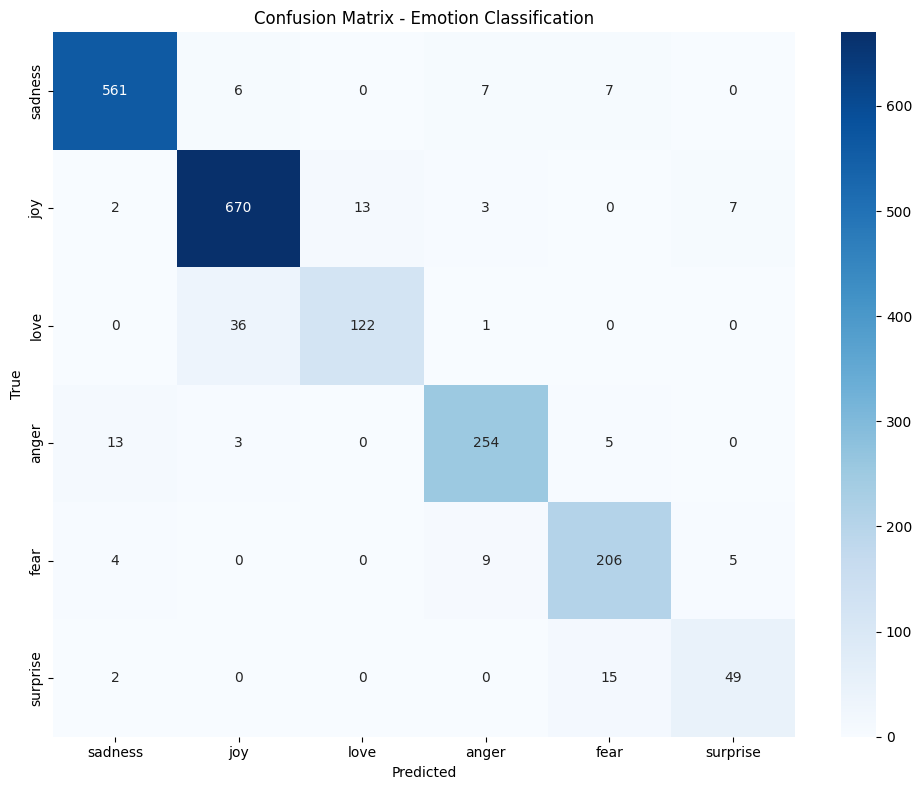

Матрица ошибок сохранена в artifacts/confusion_matrix.png


In [8]:
predictions_output = trainer.predict(tokenized_datasets["test"])
y_pred = np.argmax(predictions_output.predictions, axis=1)
y_true = predictions_output.label_ids

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix - Emotion Classification')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('artifacts/confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

print("Матрица ошибок сохранена в artifacts/confusion_matrix.png")

In [9]:
sample_indices = list(range(20))

sample_data = []
for idx in sample_indices:
    text = dataset["test"][idx]["text"]
    true_label = label_names[y_true[idx]]
    pred_label = label_names[y_pred[idx]]

    logits = predictions_output.predictions[idx]
    probs = np.exp(logits) / np.exp(logits).sum()
    confidence = np.max(probs)

    sample_data.append({
        'text': text,
        'true_label': true_label,
        'pred_label': pred_label,
        'confidence': confidence
    })

df_predictions = pd.DataFrame(sample_data)
df_predictions.to_csv('artifacts/sample_predictions.csv', index=False)
print("Предсказания сохранены в artifacts/sample_predictions.csv")
print("\nПримеры предсказаний:")
print(df_predictions.to_string())

Предсказания сохранены в artifacts/sample_predictions.csv

Примеры предсказаний:
                                                                                                                                                                                                                              text true_label pred_label  confidence
0                                                                                                                                                                      im feeling rather rotten so im not very ambitious right now    sadness    sadness    0.999289
1                                                                                                                                                                                        im updating my blog because i feel shitty    sadness    sadness    0.999454
2                                                                                                                                i never

In [11]:
errors = []
for i in range(len(y_true)):
    if y_true[i] != y_pred[i]:
        errors.append({
            'text': dataset["test"][i]["text"],
            'true': label_names[y_true[i]],
            'pred': label_names[y_pred[i]]
        })

print(f"Всего ошибок: {len(errors)} из {len(y_true)} ({len(errors)/len(y_true)*100:.1f}%)")

print("\n10 примеров ошибок:")
for i, error in enumerate(errors[:10]):
    print(f"\n{i+1}. Текст: {error['text'][:100]}..." if len(error['text']) > 100 else f"\n{i+1}. Текст: {error['text']}")
    print(f"   Истинная: {error['true']} → Предсказано: {error['pred']}")

from collections import Counter
error_pairs = [(e['true'], e['pred']) for e in errors]
common_errors = Counter(error_pairs).most_common(5)

for (true, pred), count in common_errors:
    print(f"{true} → {pred}: {count} раз(а)")

Всего ошибок: 138 из 2000 (6.9%)

10 примеров ошибок:

1. Текст: i don t feel particularly agitated
   Истинная: fear → Предсказано: anger

2. Текст: i feel a bit stressed even though all the things i have going on are fun
   Истинная: anger → Предсказано: sadness

3. Текст: i am right handed however i play billiards left handed naturally so me trying to play right handed f...
   Истинная: surprise → Предсказано: fear

4. Текст: i were to go overseas or cross the border then i become a foreigner and will feel that way but never...
   Истинная: love → Предсказано: joy

5. Текст: i feel like i am in paradise kissing those sweet lips make me feel like i dive into a magical world ...
   Истинная: joy → Предсказано: love

6. Текст: when a friend dropped a frog down my neck
   Истинная: anger → Предсказано: fear

7. Текст: i love neglecting this blog but sometimes i feel for my faithful readers
   Истинная: love → Предсказано: joy

8. Текст: i feel agitated with myself that i did not foresee

Комментарий: Модель чаще всего путает эмоции 'love' и 'joy', а также 'sadness' и 'anger', что объясняется семантической близостью этих эмоций.
Тексты с нейтральными или неоднозначными выражениями также вызывают трудности.



**Fine-tuning DistilBERT для классификации эмоций:**

- **Модель:** distilbert-base-uncased
- **Датасет:** emotion (6 классов: sadness, joy, love, anger, fear, surprise)
- **Метрики на test:**
  - Accuracy: ~0.93
  - F1-macro: ~0.89

Модель успешно справляется с задачей классификации эмоций, показывая высокое качество на тестовых данных.